<a href="https://colab.research.google.com/github/AlexandrCherezov/marketing_campaign_test_results/blob/main/marketing_campaign_eda_and_ztest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Оценка реагирования клиентов на рассылку для двух вариантов макета**



## 1 Постановка задачи и ход исследования
Клиентам были отправлены два макета электронных писем (А и Б). Для каждого клиента известен пол и возраст и взависимости от сочетиния этих параметров сформированы сегменты.  
В приложенном файле результаты отработки кампании: доставлено писем, открыто писем, сколько клиентов перешло по ссылке после открытия письма, сколько клиентов отписалось от рассылки.  


**Цель:**
- Оценить, как сегменты отреагировали на рассылку в рамках каждого макета
- Выяснить, какой из шаблонов в перспективных рассылках лучше всего отправлять клиентам
- Какие можно дать рекомендации по отправке макетов разным сегментам?

**Общее описание задачи**:
1. Провести исследовательский анализ данных
2. Сформулировать и проверить гипотезы, основываясь на имеющихся признаках
3. Сформулировать выводы по полученным результатам
4. Подготовить презентацию



**В исследовании:**

1. Познакомимся с общими данными
2. Построим воронки событий для сообщений с шаблонами А и Б без разбиения на сегменты. Определим:
- актуальность контактов
- заинтересованность клиентов в предложении (переход по ссылкам)
- лояльность клиентов (отписки)
3. Проведем статистический тест.
- Построим матрицу корреляций
- Обоснуем выбор статистического теста
- Сформулируем гипотезы и проверим их с помощью статистических тестов для выявления различий по критериям:
 - актуальность контактов
 - заинтересованность клиентов в предложении
 - лояльность клиентов
 - распределение клиентов между группами по возрасту
 - распределение клиентов между группами по гендеру (полу)
4. Проведем исследования в разрезе сегментов и выявим наличие различий между ними по последовательности событий:
- заинтересованность в предложении
 - построим воронку
 - сформулируем и проверим гипотезу
- лояльность клиентов
 - построим воронку
 - сформулируем и проверим гипотезу


**Ход исследования:**
- Загрузка данных из предоставленных файлов и подготовка их к анализу
- Обработка данных, Изучение общей информации о датафрейме
- Расчет и определение дополнительных данных
- Исследовательский анализ данных
- Формирование и проверка гипотез
- Выводы, заключения и рекомендации
- Создание презентации



ведем исследования <a class="anchor" id="library"></a>
## 2 Импорт библиотек


### 2.1. Установка дистрибутивов

### 2.2. Установка библиотек и модулей:



In [ ]:
# для извлечения и анализа данных
import pandas as pd
import numpy as np
from scipy import stats
from scipy import stats as st
import math as mth
from statistics import variance

import matplotlib.pyplot as plt
import seaborn as sns
from plotly import graph_objects as go
import os

import time # для расчета времени обработки ноутбука

import warnings
warnings.simplefilter('ignore')

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
#засечем время выполнения кода
start_time = time.time()

## 3 Загрузка и подготовка данных к анализу

Загрузим данные в свой аккаунт на Гугл.Диск.   
Изучим данные и выполним предобработку.  


In [ ]:
# Перейдем в папку с данными
os.chdir('/content/drive/MyDrive/test_resultsа')

### 3.1 Создание функций
Создадим функции, который нам потребуются в исследовании

Создадим функцию `load_files` для загрузки данных

In [ ]:
 #Функция загрузки данных в датафреймы и проверки основных параметров
def load_files(file_name):
    df= pd.read_excel('тестовое_задание.xlsx')
    print("\033[34m""\033[1m""Первые строки датафрейма")
    display(df.head(5))
    print("\033[34m""\033[1m""Информация о типах данных")
    print()
    display(df.info())
    print("\033[34m""\033[1m""Доля пропущенных значений ")
    display(round(df.isna().mean() * 100).astype(int))
    print("\033[34m""\033[1m""Количество явных дубликатов ")
    display(df.duplicated().sum())
    print("\033[34m""\033[1m""Распределение параметров ")
    display(df.describe().round())
    return(df)


In [ ]:
# Функция lower_and_strip для удаления лишних пробелов и понижения регистра,
# для заполнения пропущенных значений и присвоения данным типа category
def lower_and_strip(df, list_name):
  for i in list_name:
    df[i] = df[i].str.strip()
    df[i] = df[i].fillna('Не заполнено')
    return

In [ ]:
# Для изменения типа данных в столбце
def change_type(df, col, col_type):
  df[col] = df[col].astype(col_type)
  return

In [ ]:
# Создадим функцию для изменения типа данных столбцов
def make_datetime(df, col):
  df[col] = pd.to_datetime(df[col], unit='s')
  return

In [ ]:
# Создадим функцию для построения гистограммы
def orders_distr(df, ax, event):

    ax =  df.plot(y='возраст'
                                        , kind = 'hist'
                                        , figsize=(10,5)
                                        , bins=20
                                        , ax=ax
                                        , grid=True, )
    #plt.legend(fontsize=14, bbox_to_anchor=(1.6, 1))
    plt.title(f'Распределение \nпо {event}\n', fontsize=20, color = "b")
    plt.xlabel(f"{event}", fontsize = 16, color = "b")
    plt.ylabel("Количество событий", fontsize = 16, color = "b")
    #plt.axhline (y=np.nanmean (df.y ))

    return

In [ ]:
# Создадим функцию для построения гистограммы с учетом выделения макета
def orders_distr_mark(df, ax, event, mark):

    ax =  df.query('макет == @mark').plot(y='возраст'
                                        , kind = 'hist'
                                        , figsize=(15,5)
                                        , bins=30
                                        , ax=ax
                                        , grid=True, )
    #plt.legend(fontsize=14, bbox_to_anchor=(1.6, 1))
    plt.title(f'Распределение \nпо {event}\n для макета {mark}', fontsize=20, color = "b")
    plt.xlabel(f"{event}", fontsize = 16, color = "b")
    plt.ylabel("Количество событий", fontsize = 16, color = "b")
    plt.axvline (x=np.nanmean (df['возраст']), color='green', linestyle='--', linewidth= 3 , label='Avg')
    plt.axvline (x=df['возраст'].median() , color='red', linestyle='-.', linewidth= 3 , label='Median')
   # plt.axvline

    return

In [ ]:
# Создадим функцию для построения "ящика с усами"
def orders_box(df, ax, event):

    ax =  df.boxplot(['возраст'], figsize=(5,5))
    plt.title(f'Распределение \nпо {event}\n', fontsize=20, color = "b")
    plt.ylabel(f"{event}", fontsize = 16, color = "b")
    plt.xlabel("Количество событий", fontsize = 16, color = "b")

    return

In [ ]:
# Создадим функцию для построения "ящика с усами" с учетом выделения периода макета
def orders_box_mark(df, ax, event, mark):

    ax =  df.query('макет == @mark').boxplot(['возраст'], figsize=(15,15))
    plt.title(f'Распределение \nпо {event}\n для макета {mark}', fontsize=20, color = "b")
    plt.ylabel(f"{event}", fontsize = 16, color = "b")
    plt.xlabel("Количество событий", fontsize = 16, color = "b")
    #plt.ylim(0,40)

    return

In [ ]:
# Для построения двух графиков на одном поле
def plot_two_in_one(mark):
  # задаём размер сетки для графиков
  plt.figure(figsize=(35, 8))
  # в первой ячейке строим распределение по группе А
  ax1 = plt.subplot(1, 2, 1)
  # вызываем функцию
  orders_distr_mark(df, ax1, 'Возраст', mark)
  # во второй ячейке строим распределение по группе В
  ax2 = plt.subplot(1, 2, 2)
  # вызываем функцию
  orders_box_mark(df, ax2, 'Возраст', mark)

  return

In [ ]:
# Создадим функцию для построения столбчатых диаграмм
def build_bar(df, col_qry, mark, col_group, col_agg, action, event):
    # строим столбчатую диаграмму, отражающую количество событий в зависимости от времени
    t1 = df.query('макет == @mark').groupby(col_group).agg({col_agg:action}).sort_values(col_group)
    ax = t1.plot(
    kind='bar',
    y= col_agg,
    linewidth=5,
    alpha=0.7,
    label= f"Шаблон {mark}",
    figsize=(5,5),
    color = ['DeepPink','DodgerBlue']
    )
    plt.title(f'{event}\n для Шаблона {mark}\n', fontsize=20, color = "b")
    #plt.legend(fontsize=14, bbox_to_anchor=(2, 1))
    plt.xticks(rotation=0, fontsize=12, color = "b")
    plt.yticks(rotation=0, fontsize=12, color = "b")
    plt.xlabel('Пол клиента', fontsize=14, color = "b")
    plt.ylabel(f'{event}', fontsize=14, color = "b")

    return

In [ ]:
# Для построения двух графиков на одном поле
def plot_two_in_one_bar():
  # задаём размер сетки для графиков
  plt.figure(figsize=(10, 18))
  # в первой ячейке строим распределение по группе А
  ax1 = plt.subplot(2, 1, 1)
  # вызываем функцию
  build_bar(df, ax1, 'макет', "А", "пол", "номер_клиента", "count", "В зависимости от пола")
  # во второй ячейке строим распределение по группе В
  ax2 = plt.subplot(2, 1, 2)
  # вызываем функцию
  build_bar(df, ax2, 'макет', "Б", "пол", "номер_клиента", "count", "В зависимости от пола")

  return

In [ ]:
# Построим груговую диаграмму и увидим доли клиентов в группах
def build_pie(df, ax, col_qry, mark, col_group, col_agg, action, event):
    exp = (0.1,0.1)
    t1 = df.query('макет == @mark').groupby(col_group).agg({col_agg:action}).sort_values(col_group)
    display(t1)
    #data.groupby('expid')['deviceidhash'].agg('nunique').sort_values(ascending=False)\
    t1.plot(kind='pie',
            y= col_agg,
            figsize=(5,5),
            colors = ['yellow','LawnGreen','DeepPink','DodgerBlue'], \
                  autopct='%1.1f%%',fontsize=14, explode=exp)
    plt.title('Распределение клиентов \nв разрезе групп \n\n', fontsize=20, color = "b")
    plt.legend(fontsize=14, bbox_to_anchor=(1.5, 1))
    plt.xticks(rotation=0, fontsize=12, color = "b")
    plt.yticks(rotation=0, fontsize=12, color = "b")

    #plt.show()

In [ ]:
# Создадим функцию для построения круговых диаграмм
def build_pie_along(df, col_qry, mark, col_group, col_agg, action, event, sector=2):
    # строим столбчатую диаграмму, отражающую количество событий в зависимости от времени
    if sector == 2:
      exp = (0.1,0.1)
    elif sector == 3:
      exp = (0.1,0.1, 0.1)
    t1 = df.groupby(col_group).agg({col_agg:action}).sort_values(col_group)
    ax = t1.plot(
      kind='pie',
      y= col_agg,
      label= f"Шаблон {mark}",
      figsize=(5,5),
      colors = ['yellow','LawnGreen','DeepPink','DodgerBlue'],
      autopct='%1.1f%%',
      fontsize=14,
      explode=exp
      )
    plt.title(f'{event}\n ', fontsize=20, color = "b")
    #plt.legend(fontsize=14, bbox_to_anchor=(2, 1))
    plt.xticks(rotation=0, fontsize=12, color = "b")
    plt.yticks(rotation=0, fontsize=12, color = "b")
    plt.xlabel('Пол клиента', fontsize=14, color = "b")
    plt.ylabel(f'{event}', fontsize=14, color = "b")

    return

In [ ]:
# Создадим функцию для построения круговых диаграмм
def build_pie(df, col_qry, mark, col_group, col_agg, action, event):
    # строим столбчатую диаграмму, отражающую количество событий в зависимости от времени
    exp = (0.1,0.1)
    t1 = df.query('макет == @mark').groupby(col_group).agg({col_agg:action}).sort_values(col_group)
    #display(t1)
    ax = t1.plot(
      kind='pie',
      y= col_agg,
      label= f"Шаблон {mark}",
      figsize=(5,5),
      colors = ['yellow','LawnGreen','DeepPink','DodgerBlue'],
      autopct='%1.2f%%',
      fontsize=14,
      explode=exp
      )
    plt.title(f'{event}\n для Шаблона {mark}\n', fontsize=20, color = "b")
    #plt.legend(fontsize=14, bbox_to_anchor=(2, 1))
    plt.xticks(rotation=0, fontsize=12, color = "b")
    plt.yticks(rotation=0, fontsize=12, color = "b")
    plt.xlabel('Пол клиента', fontsize=14, color = "b")
    plt.ylabel(f'{event}', fontsize=14, color = "b")

    return

In [ ]:
# Построение воронки событий
def funnel(data, events_count, model):
    # построим воронку событий
    fig = go.Figure(go.Funnel(
        y = data['event'],
        x = data[events_count],
        textposition = "auto",
        textinfo = "value + percent previous ",
        opacity = 0.65, marker = {"color": ['yellow','LawnGreen','DeepPink','Darkorange','DodgerBlue'],
        "line": {"width": [3, 3, 3, 3], "color": ["wheat", "wheat", "wheat", "wheat", "wheat"]}},
        connector = {"line": {"color": "royalblue", "dash": "dot", "width": 3}})
                      )
    fig.update_layout(
        template = 'simple_white',
        title={
            'text': f"Воронка событий Шаблон {model}",
            'y':0.9,
            'x':0.54,
            'xanchor': 'center',
            'yanchor': 'top',
            #hoverinfo = "text",
            'font': {'size': 20, 'color': 'blue'}
                },
        width = 600,
        height = 400
        )
    fig.update_traces(textfont=dict(size=12, color='darkblue'))
    fig.show()

    return

In [ ]:
# Построение спаренной воронки событий
def funnel_twice(data, events_count_a, model_a, events_count_b, model_b):
    # построим воронку событий
    fig = go.Figure()

    fig.add_trace(go.Funnel(
        y = data['event'],
        x = data[events_count_a],
        name = f"Шаблон {model_a}",
        textposition = "auto",
        textinfo = "value + percent previous ",
        opacity = 0.95,
        #marker = {"color": ['yellow','LawnGreen','DeepPink','Darkorange','DodgerBlue'],
        #"line": {"width": [3, 3, 3, 3], "color": ["wheat", "wheat", "wheat", "wheat", "wheat"]}},
        connector = {"line": {"color": "royalblue", "dash": "dot", "width": 3}})
                      )
    fig.add_trace(go.Funnel(
        y = data['event'],
        x = data[events_count_b],
        name = f"Шаблон {model_b}",
        textposition = "outside",
        textinfo = "value + percent previous ",
        opacity = 0.95,
        #marker = {"color": ['yellow','LawnGreen','DeepPink','Darkorange','DodgerBlue'],
        #"line": {"width": [3, 3, 3, 3], "color": ["wheat", "wheat", "wheat", "wheat", "wheat"]}},
        connector = {"line": {"color": "royalblue", "dash": "dot", "width": 3}})
                      )

    fig.update_layout(
        template = 'simple_white',
        title={
            'text': f"Воронка событий Шаблон {model_a} и Шаблон {model_b}",
            'y':0.9,
            'x':0.54,
            'xanchor': 'center',
            'yanchor': 'top',
            #hoverinfo = "text",
            'font': {'size': 20, 'color': 'blue'}
                },
        width = 900,
        height = 400
        )
    fig.update_traces(textfont=dict(size=12, color='darkblue'))
    fig.show()

    return

In [ ]:
# Расчет и построение воронки
def grouping_events(clients_pie):
    # Сгруппируем данные
    #clients_pie = df.groupby('макет').agg({'отправлено':'sum','доставлено':'sum','открыто':'sum', last_event:'sum'})\
    #    .T.reset_index()
    # Переименуем столбцы
    clients_pie.columns = ['event', 'clients_id_a', 'clients_id_b']
    # Для шаблона А
    # Рассчитаем долю пользователей, которые переходят на следующий шаг воронки и созраним результат в столбце conv
    # Результат представим в процентах и округлим до одного знака после запятой
    clients_pie['conv_a'] =  (clients_pie['clients_id_a'] / clients_pie['clients_id_a'].shift()).fillna('-')
    # Также рассчитаем конверсию каждого шага воронки к первому действию.
    # Результат представим в процентах и запишем в столбце conv_to_fst_step
    clients_pie['conv_a_to_fst_step'] =  clients_pie['clients_id_a'] / clients_pie.loc[0,'clients_id_a']

    # Аналогичный расчет для Шаблона Б
    clients_pie['conv_b'] =  (clients_pie['clients_id_b'] / clients_pie['clients_id_b'].shift()).fillna('-')
    clients_pie['conv_b_to_fst_step'] =  clients_pie['clients_id_b'] / clients_pie.loc[0,'clients_id_b']
    pd.options.display.float_format = '{:.1%}'.format

    # Изменим имеющийся порядок столбцов
    cols = clients_pie.columns.tolist()
    cols = cols[:2] + cols[3:5]+ cols[2:3]+ cols[-2:]
    clients_pie = clients_pie[cols]

    print('\033[92m''\033[1m''\033[4m''Таблица конверсии''\033[0m')
    display(clients_pie)

    # Визуализируем воронку событий для Шаблона А
    #funnel(clients_pie, 'clients_id_a', 'А')
    print()
    print('\033[92m''\033[1m''\033[4m''Визуализируем воронку событий для обоих шаблонов''\033[0m')
    print()
    # Визуализируем воронку событий для обоих шаблонов на одной диаграмме
    funnel_twice(clients_pie, 'clients_id_a', 'А', 'clients_id_b', 'Б')

    return

In [ ]:
# Для расчета доли  доставленных сообщений к отправленным
def sent_deliv(gr, sent, deliv, param_1, param_2):
  print(f'\033[34mГруппа {gr}\033[0m\n\
    {param_1} - {sent}\n\
    {param_2} - {deliv}\n\
    конверсия {(deliv / sent):.2%}')

In [ ]:
# Расчет z-теста
def z_test(successes, trials, alpha, bonferroni=1):


    alpha = alpha
    successes = successes
    trials = trials

    # применим поправку Бонферрони
    alpha = alpha / bonferroni

    # пропорция успехов в первой группе:
    p1 = successes[0] / trials[0]

    # пропорция успехов во второй группе:
    p2 = successes[1] / trials[1]

    # пропорция успехов в комбинированном датасете:
    p_combined = (successes[0] + successes[1]) / (trials[0] + trials[1])

    # разница пропорций в датасетах
    difference = p1 - p2

    # считаем статистику в ст.отклонениях стандартного нормального распределения
    z_value = difference / mth.sqrt(p_combined * (1 - p_combined) *
                                    (1 / trials[0] + 1 / trials[1]))



    print(f'\n\
          пропорция успехов в первой группе p1 =  {p1} \n\
          пропорция успехов во второй группе p2 = {p2}\n\
          пропорция успехов в комбинированном датасете p_combined = {p_combined}\n\
          разница пропорций в датасетах difference =  {difference}\n\
          z_value {z_value}')

    # задаем стандартное нормальное распределение (среднее 0, ст.отклонение 1)
    distr = st.norm(0, 1)

    # проверяем двухстороннюю гипотезу, при расчете p_value умножаем на 2
    p_value = (1 - distr.cdf(abs(z_value))) *2

    print("\033[32m"'z-test:\np-значение: ', p_value)

    if p_value < alpha:
        print("\033[31m"'Отвергаем нулевую гипотезу: между долями есть значимая разница')
    else:
        print(
            "\033[34m"'Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными'
        )

    return

In [ ]:
# Подготовка данных и проведение статистических тестов

def prepear_test(df_A, df_B, param_1, param_2, alpha, bonferroni = 1):

  # Посмотрим соотношение между количеством  отправленных и доставленных сообщений внутри каждой группы.
  sent_A = df_A[param_1].sum()
  delivered_A = df_A[param_2].sum()
  sent_B = df_B[param_1].sum()
  delivered_B = df_B[param_2].sum()

  sent_deliv('A', sent_A, delivered_A, param_1, param_2)
  sent_deliv('Б', sent_B, delivered_B, param_1, param_2)

  # Посчитаем статистику
  # критический уровень статистической значимости
  alpha = alpha

  # применим поправку Бонферрони
  alpha = alpha / bonferroni

  delivered = np.array([delivered_A, delivered_B])
  sent = np.array([sent_A, sent_B])

  #print(dead, all_part)
  print(20*'-')
  print('Посчитаем статистику, проведем z-test')
  # проведем z-тест
  z_test(delivered, sent, alpha, bonferroni)


  p_value = st.ttest_ind(df_A[param_2],
                       df_B[param_2],
                       equal_var=False,
                       alternative='two-sided')
  print()
  print("\033[32m"'t-test:\np-значение: ', p_value[1])

  if p_value[1] > alpha:
    print("\033[34m"'Не удалось отвергнуть нулевую гипотезу. Принимаем нулевую гипотезу')
  else:
    print("\033[31m"'Нулевая гипотеза отвергнута. Принимаем альтернативную гипотезу')

  return


In [ ]:
# Для проведения t - теста
def t_test(df_A, df_B, col, bonferroni = 1, alpha = 0.05):
    p_value = st.ttest_ind(df_A[col],
                          df_B[col],
                          equal_var=False,
                          alternative='two-sided')

    print("\033[32m"'p-значение: ', round(p_value[1], 3))

    # применим поправку Бонферрони
    alpha = alpha / bonferroni

    if p_value[1] > alpha:
        print("\033[34m"'Не удалось отвергнуть нулевую гипотезу. Принимаем нулевую гипотезу')
    else:
        print("\033[31m"'Нулевая гипотеза отвергнута. Принимаем альтернативную гипотезу')

    return

In [ ]:
# Для проведения статистического теста при сегментации клиентов
def iterate_over_segments(df, event_1, event_2, bonferroni = 3, alpha = 0.05):
    # Осуществим перебор комбинаций сегментов:
    # Для уникальных значений столбца "возраст_сегм"
    for i in sorted(df['возраст_сегм'].unique()):
      # Для уникальных значений столбца "пол"
      for j in sorted(df['пол'].unique()):
        # Переберем комбинации
        print(f"\033[33m\033[1mДиапазон возраста '{i}', гендер '{j}'")
        print()

        # Создадим датасеты (выборки) с клиетами группы А и группы Б
        df_A = df[df['макет'] == "А"]
        df_B = df[df['макет'] == "Б"]

        # Проведем тест
        prepear_test(
            df_A.loc[(df_A['возраст_сегм'] == i) & (df_A['пол'] == j)],
            df_B.loc[(df_B['возраст_сегм'] == i) & (df_B['пол'] == j)],
            event_1, event_2, alpha, bonferroni)

        print()
        print('\033[33m\033[1m*' * 100)
        print()

In [ ]:
# Построение матрицы корреляции
def coef_corr(list_name):
    # зададим матрицу корреляции
    # возьмем только столбцы с числовыми значениями:
    df_corr = list_name.corr()

    # построим матрицу
    fig, ax = plt.subplots(figsize=(8,3))
    sns.heatmap(df_corr, fmt='.0%', annot = True, cmap="vlag", cbar=False)
    plt.title('Матрица корреляции\n', color = 'b', fontsize = 12)
    plt.xticks(rotation=0, fontsize=10, color = "b")
    plt.yticks(rotation=0, fontsize=10, color = "b")
    plt.show()

### 3.2. Загрузка датафреймов и изучение данных

Файл `тестовое_задание.xlsx`   

Структура файла

|Столбец |Описание ||
|:-----|:----|----:|
Номер клиента|Уникальный номер клиента	в рассылке
Макет| Шаблон А или Шаблон Б
Доставлено| 1 (да) или 0 (нет)
Открыто| 1 (да) или 0 (нет)
Переход по ссылке| 1 (да) или 0 (нет)
Отписки| 1 (да) или 0 (нет)
Возраст| Возраст клиента
Пол| Пол клиента


In [ ]:
df = load_files('тестовое_задание.xlsx')

Первые строки датафрейма


,Номер клиента,Макет,Доставлено,Открыто,Переход по ссылке,Отписки,Возраст,Пол
0,1,Шаблон Б,100.0%,1,0,0,4169.0%,М
1,2,Шаблон Б,100.0%,1,0,0,2824.9%,Ж
2,3,Шаблон Б,100.0%,1,0,0,3143.6%,М
3,4,Шаблон Б,100.0%,1,0,0,3456.4%,М
4,5,Шаблон Б,100.0%,1,0,0,3526.0%,М


Информация о типах данных

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42126 entries, 0 to 42125
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Номер клиента      42126 non-null  int64  
 1   Макет              42126 non-null  object 
 2   Доставлено         23007 non-null  float64
 3   Открыто            42126 non-null  int64  
 4   Переход по ссылке  42126 non-null  int64  
 5   Отписки            42126 non-null  int64  
 6   Возраст            42126 non-null  float64
 7   Пол                42126 non-null  object 
dtypes: float64(2), int64(4), object(2)
memory usage: 2.6+ MB


None

Доля пропущенных значений 


Номер клиента         0
Макет                 0
Доставлено           45
Открыто               0
Переход по ссылке     0
Отписки               0
Возраст               0
Пол                   0
dtype: int64

Количество явных дубликатов 


0

Распределение параметров 


,Номер клиента,Доставлено,Открыто,Переход по ссылке,Отписки,Возраст
count,4212600.0%,2300700.0%,4212600.0%,4212600.0%,4212600.0%,4212600.0%
mean,2106400.0%,100.0%,0.0%,0.0%,0.0%,3600.0%
std,1216100.0%,0.0%,0.0%,0.0%,0.0%,500.0%
min,100.0%,100.0%,0.0%,0.0%,0.0%,2300.0%
25%,1053200.0%,100.0%,0.0%,0.0%,0.0%,3200.0%
50%,2106400.0%,100.0%,0.0%,0.0%,0.0%,3600.0%
75%,3159500.0%,100.0%,0.0%,0.0%,0.0%,4000.0%
max,4212600.0%,100.0%,100.0%,100.0%,100.0%,5200.0%


Отметим, что:
- количество записей - 42136
- количество клиентов - 42136
- названия столбцов не соблюдают правила написания кода PEP8
- данные в столбцах `Доставлено` и `Возраст` представлены в формате float
- в столбце `Доставлено` пропущено 45% значений
- явные дубликаты отсутствуют
- стандартное отклонение в столбце `Возраст` показывает, что 68% клиентов находятся в сравнительно узком диапазоне от 31 до 41 года
- порядок следования столбцов в датафрейме не совсем удобен - персрнальные данные о клиенте расположены в начале и конце таблицы, а данные о событиях разрывают их.

Обработаем:
- названия столбцов приведем к стилю `lower_case_with_underscores` (слова из маленьких букв с подчеркиваниями)
- данные в столбцах `Доставлено` и `Возраст` приведем к типу int
- выясним причину отсутствия значений в столбце `Доставлено` и примем решение о заполнении или не заполнении пропущенных значений
- изменим порядок следования столбцов


# 4 Обработаем данные

In [ ]:
# Названия столбцов приведем к стилю lower_case_with_underscores
df.columns = df.columns.str.lower().str.replace(' ','_')

выясним причину отсутствия значений в столбце Доставлено и примем решение о заполнении или не заполнении пропущенных значений

In [ ]:
#  Уникальные значения в столбце "доставлено"
df['доставлено'].unique()

array([ 1., nan])

In [ ]:
# Ознакомимся с некоторыми записями
df[df['доставлено'].isna()].head()

,номер_клиента,макет,доставлено,открыто,переход_по_ссылке,отписки,возраст,пол
1875,1876,Шаблон Б,NaN,0,0,0,3114.0%,М
1877,1878,Шаблон Б,NaN,0,0,0,4258.9%,Ж
1878,1879,Шаблон Б,NaN,0,0,0,3505.8%,М
1880,1881,Шаблон Б,NaN,0,0,0,3171.5%,М
1883,1884,Шаблон Б,NaN,0,0,0,3354.0%,М


In [ ]:
df.columns[2:6]

Index(['доставлено', 'открыто', 'переход_по_ссылке', 'отписки'], dtype='object')

In [ ]:
# Удостоверимся, что для незаполненных записей в столбце "доставлено"
# уникальные значения в столбцах 'открыто', 'переход_по_ссылке', 'отписки' имеют значения только 0
for i in df.columns[2:6]:
  print(i, df.loc[df['доставлено'].isna(), i].unique())

доставлено [nan]
открыто [0]
переход_по_ссылке [0]
отписки [0]


Увиденное позволяет утверждать, что незаполненные позиции в столбце `доставлено` означают суть - "не доставлено" и могут быть заменены нулями

In [ ]:
df['доставлено'] = df['доставлено'].fillna(0)

In [ ]:
# данные в столбцах Доставлено и Возраст приведем к типу int
list_2 = ['доставлено', 'возраст']
change_type(df, list_2, 'int')

In [ ]:
# Для удобства дальнейших расчетов и определения верхнего уровня воронки добавим столбец "отправлено"
# каждой ячейке в нем присвоим значение, равное 1

df.insert (loc= 2 , column='отправлено', value=1)

In [ ]:
# В столбце "макет" избавимся от слова "Шаблон"
df['макет'] = df['макет'].replace('Шаблон Б', 'Б')
df['макет'] = df['макет'].replace('Шаблон А', 'А')

In [ ]:
df.columns

Index(['номер_клиента', 'макет', 'отправлено', 'доставлено', 'открыто',
       'переход_по_ссылке', 'отписки', 'возраст', 'пол'],
      dtype='object')

In [ ]:
# Изменим порядок следования столбцов
cols_df = df.columns.tolist()
cols_df = cols_df[:2] + cols_df[-2:] + cols_df[2:-2]
df = df[cols_df]

In [ ]:
# Проверим, присутствует ли один и тот же клиент в разных группах.
# Убедимся, что не присутствует
pd.merge(df.query("макет == 'А'")[['номер_клиента', "макет"]],
         df.query("макет == 'Б'")[['номер_клиента', "макет"]],
         on = 'номер_клиента')

,номер_клиента,макет_x,макет_y


Для последующей оценки проведенного теста в разрезе сегментов разобьем клиентов по возрасту на диапазоны (для удобства обработки и восприятия обозначим диапазоны цифрами):
- до 27 лет - 20
- от 28 лет включительно до 40 лет - 30
- от 40 лет включительно - 40


In [ ]:
# Добавим сегментацию по возрасту
# Добавим новый столбец
df.insert (loc= 3 , column='возраст_сегм', value=20)
# Произведем сегментацию
df.loc[df['возраст'] >= 28, 'возраст_сегм'] = 30
df.loc[df['возраст'] >= 40, 'возраст_сегм'] = 40

In [ ]:
# Посмотрим, как распределились клиенты
df.groupby('возраст_сегм').agg({'номер_клиента':'count'})

,номер_клиента
возраст_сегм,
20,3676
30,28005
40,10445


Достаточность длительности теста  

Для получения достоверных результатов рекомендуется проверить - достаточная ли длительность теста выбрана, чтобы мы могли получить статистически значимый результат.  
Для этого можно воспользоваться калькулятором https://vwo.com/tools/ab-test-duration-calculator/ и определить минимально необходимую продолжительность теста.  
В настоящем задании отсутствуют данные, на основании которых можно судить о достаточности времени проведения теста. Мы примем, что этот параметр был учтен на этапе формирования и запуска теста.


# 5 Исследование
- провести общее исследование
 - гистограмма, боксплот, выброс
 - определим равенство групп и как это влияет
 - определим воронку
 - какое место в воронке занимает отказ от рассылки?
 - сформируем:
   - одну воронку как отправлено - доставлено -	открыто -	переход_по_ссылке
   - вторую воронку как отправлено - доставлено -	открыто -	отписки
- построим для каждого шаблона воронку, визуализируем ее
- посмотрим необходимость корреляции
- проведем А\В тест
 - сравним средние для:
  - распределения по полу
  - распределения по возрасту
 - определим вид теста и обоснуем его применение
 - сформулируем нулевую гипотезу
 - определим коэффициент поправки - Бонферрони или иной
  - определим величину корректирующего коэффциента
  


### 5.1 Познакомимся с общими данными

In [ ]:
# Какие события зафиксированы в нашем исследовании
df.columns[4:].to_list()

['пол', 'отправлено', 'доставлено', 'открыто', 'переход_по_ссылке', 'отписки']

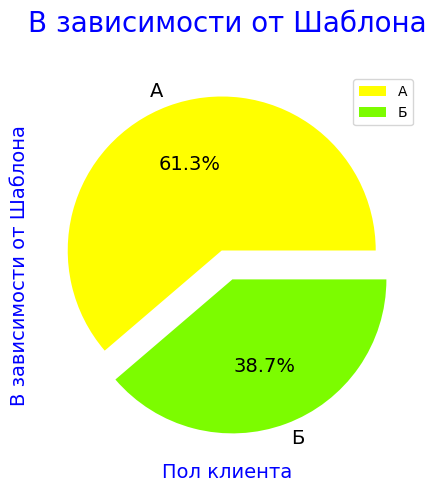

In [ ]:
# Посчитаем, насколько равномерно клиенты распределены между группами
build_pie_along(df, 'макет', i, "макет", "номер_клиента", "count", "В зависимости от Шаблона")

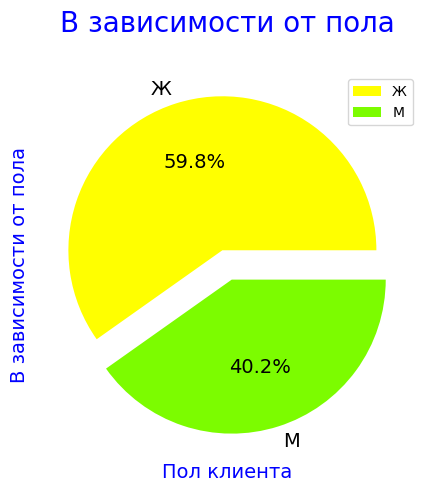

In [ ]:
# Ознакомимся, насколько равномерное гендерное распределение клиентов
build_pie_along(df, 'макет', i, "пол", "номер_клиента", "count", "В зависимости от пола")

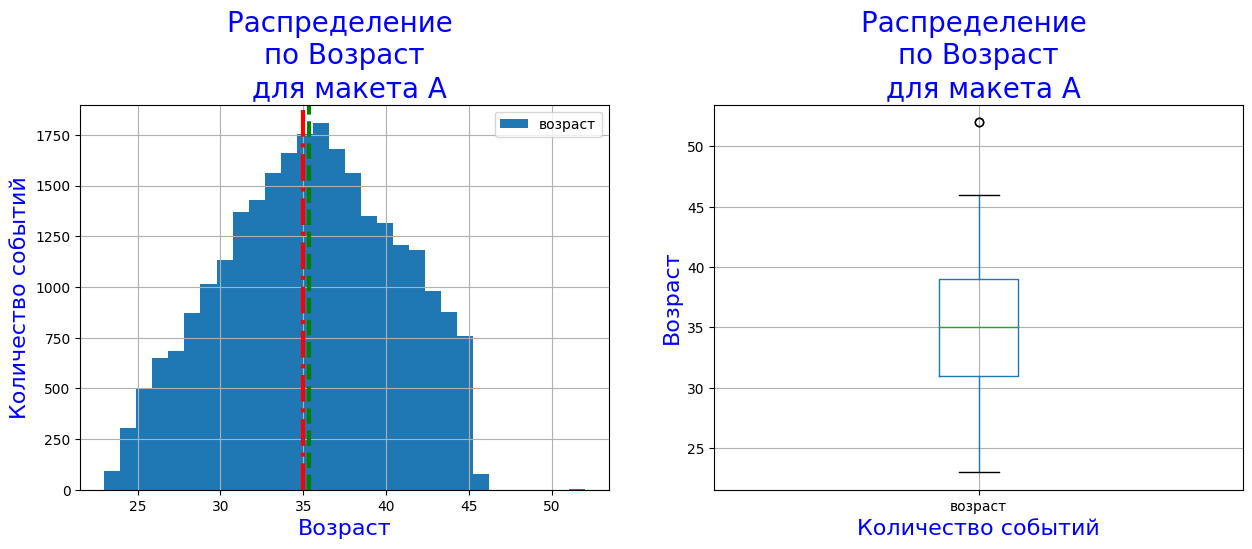

In [ ]:
# Как распределены клиенты по возрасту в группе А
plot_two_in_one('А')

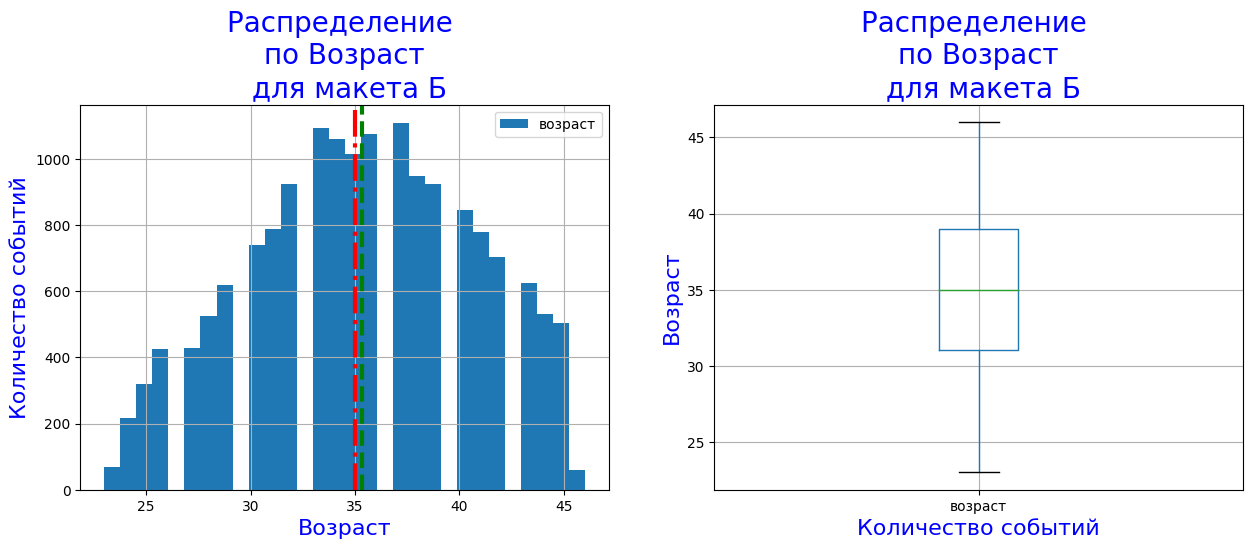

In [ ]:
# Как распределены клиенты по возрасту в группе Б
plot_two_in_one('Б')

In [ ]:
# Количество клиентов в зоне выброса
df.query('возраст > 50')

,номер_клиента,макет,возраст,возраст_сегм,пол,отправлено,доставлено,открыто,переход_по_ссылке,отписки
20830,20831,А,52,40,М,1,0,0,0,0
31517,31518,А,52,40,М,1,0,0,0,0


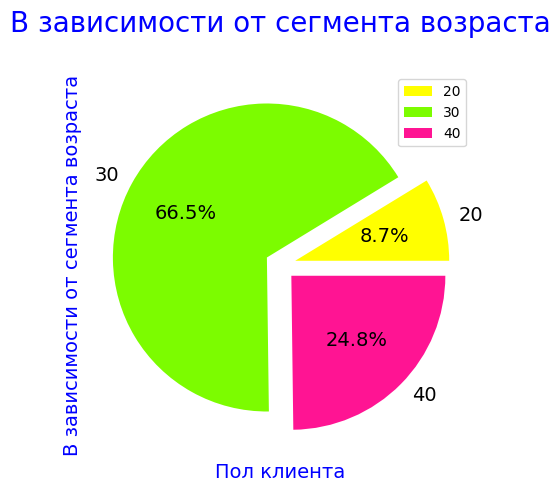

In [ ]:
# Ознакомимся, насколько равномерное распределение клиентов по диапазону возраста
build_pie_along(df, 'макет', i, "возраст_сегм", "номер_клиента", "count", "В зависимости от сегмента возраста", 3)

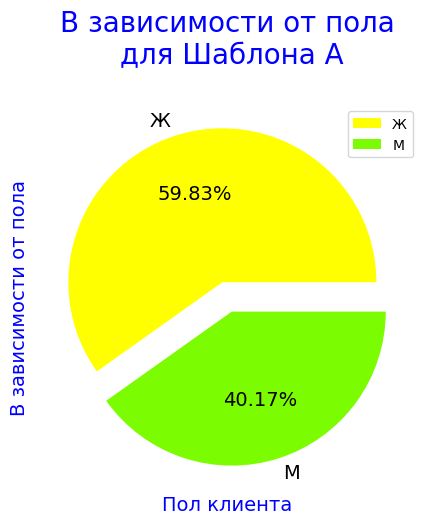

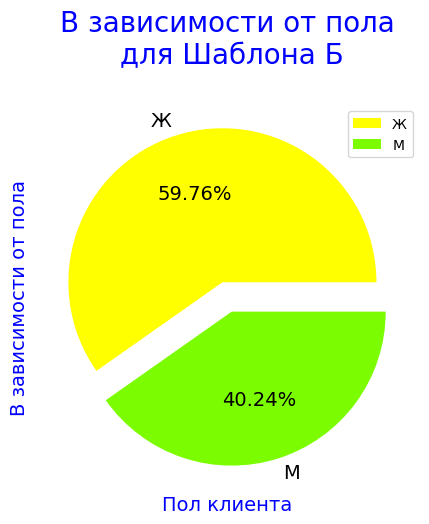

In [ ]:
# Как распределены клиенты по гендеру в группах
for i in ['А', 'Б']:
  build_pie(df, 'макет', i, "пол", "номер_клиента", "count", "В зависимости от пола")

- Рассылка поделена неравномерно между макетами - на шаблон А приходится 61%, на шаблон Б - 39% от всей рассылки. Точность эксперимента будет близка к максимальной при соотношении чмсленности групп 50/50. Тем не менее реалии бизнеса требуют быстрого исследования изменений. В статье ["Дисбаланс в А/В. Есть ли разница между 99%/1% и 50%/50% в экспериментах"](https://medium.com/statistics-experiments/%D0%B4%D0%B8%D1%81%D0%B1%D0%B0%D0%BB%D0%B0%D0%BD%D1%81-%D0%B2-a-b-%D1%82%D0%B5%D1%81%D1%82%D0%B0%D1%85-%D0%B5%D1%81%D1%82%D1%8C-%D0%BB%D0%B8-%D1%80%D0%B0%D0%B7%D0%BD%D0%B8%D1%86%D0%B0-%D0%BC%D0%B5%D0%B6%D0%B4%D1%83-99-1-%D0%B8-50-50-%D0%B2-%D1%8D%D0%BA%D1%81%D0%BF%D0%B5%D1%80%D0%B8%D0%BC%D0%B5%D0%BD%D1%82%D0%B0%D1%85-11c8f4fe7eb4) делается вывод о достаточности объема трафика более 20% для обнаружения изменений (отличий).
- Клиентская база в рассылке в зависимости от пола клиента представлена неравномерно - 60% - женщины, 40% - мужчины
- Возрастные группы представлены в виде нормального распределения для обеих макетов. Для шаблона А присутствуют два выброса за венрхнюю границу. Пренебрежем этими значениями и удалим их
- Медианный и средний возрасты клиентов обеих выборок различаются нехначительно и равны 35 годам
- Гендерные пропорции для групп с разными макетами одинаковы


In [ ]:
# Удалим записи для клиентов в возрасте более 50 лет
df = df.query('возраст <= 50')

## 5.1. Воронка событий

Сформируем и изучим воронку событий.   
Узнаем, сколько клиентов доходит до перехода по ссылке, а сколько — «застревает» на предыдущих шагах и на каких именно шагах




Можно заметить, что последовательность событий 'отправлено' - 'доставлено' - 'открыто' - 'переход_по_ссылке' представляет собой воронку событий. Рассчитаем воронку и построим ее для каждого из макетов

In [ ]:
# Сгруппируем данные, сформируем датафрейм для построения воронки
clients_pie = df.groupby('макет').agg({'отправлено':'sum','доставлено':'sum','открыто':'sum', 'переход_по_ссылке':'sum'})\
        .T.reset_index()
# Построим воронку
grouping_events(clients_pie)

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,отправлено,25807,-,100.0%,16317,-,100.0%
1,доставлено,10023,38.8%,38.8%,12984,79.6%,79.6%
2,открыто,2065,20.6%,8.0%,1875,14.4%,11.5%
3,переход_по_ссылке,382,18.5%,1.5%,390,20.8%,2.4%



Визуализируем воронку событий для обоих шаблонов



Последовательность событий 'отправлено' - 'доставлено' характеризует актуальность контактов.  
Последовательность событий 'доставлено' - 'открыто' - 'переход_по_ссылке' характеризует заинтересованность клиента, его лояльность.  

Рассмотрим эти последовательности раздельно друг от друга.

### Aктуальность контактов
Построим воронку для последовательности событий 'отправлено' - 'доставлено' для каждого из макетов

In [ ]:
# Сгруппируем данные, сформируем датафрейм для построения воронки
clients_pie_1 = df.groupby('макет').agg({'отправлено':'sum','доставлено':'sum'})\
        .T.reset_index()
# Построим воронку
grouping_events(clients_pie_1)

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,отправлено,25807,-,100.0%,16317,-,100.0%
1,доставлено,10023,38.8%,38.8%,12984,79.6%,79.6%



Визуализируем воронку событий для обоих шаблонов



- Сравним переходы и увидим, что для шаблона Б доля доставленных сообщений вдвое больше, что может говорить о более качественной и актуальной контактной информации для этой группы. Вероятно, клиенты здесь были заведены в базу сравнительно недавно относительно клиентов с шаблоном А

### Заинтересованность в предложении
Построим воронку для последовательности событий 'доставлено' - 'открыто' - 'переход_по_ссылке' для каждого из макетов

In [ ]:
# Сгруппируем данные, сформируем датафрейм для построения воронки
clients_pie = df.groupby('макет').agg({'доставлено':'sum','открыто':'sum', 'переход_по_ссылке':'sum'})\
        .T.reset_index()
# Построим воронку
grouping_events(clients_pie)

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,10023,-,100.0%,12984,-,100.0%
1,открыто,2065,20.6%,20.6%,1875,14.4%,14.4%
2,переход_по_ссылке,382,18.5%,3.8%,390,20.8%,3.0%



Визуализируем воронку событий для обоих шаблонов



Сравним конверсии в разрезе макетов (шаблонов)
- Клиенты с шаблоном А в полтора раза чаще открывали полученные (доставленные) сообщения, но все-же их конверсия относительно количества отправленных сообщений остается ниже, что также в совокупности можно объяснить слабой актуальностью контактов и давностью контактов - клиентам было интересно посмотреть содержание сообщения
- открыв (прочитав) сообщение далее по ссылке немного чаще переходили клиенты с шаблоном Б, но это не компенсировало низкую конверсиб предыдущего этапа. Конечная конверсия этапа "переход_по_ссылке" к этапу "доставлено" для группы Б оказалась почти на четверть ниже, чем для группы А


### Лояльность клиентов
Построим воронку для последовательности событий 'доставлено' - 'открыто' - 'отписки' для каждого из макетов

In [ ]:
# Сгруппируем данные, сформируем датафрейм для построения воронки
clients_pie = df.groupby('макет').agg({'доставлено':'sum','открыто':'sum', 'отписки':'sum'})\
        .T.reset_index()
# Построим воронку
grouping_events(clients_pie)

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,10023,-,100.0%,12984,-,100.0%
1,открыто,2065,20.6%,20.6%,1875,14.4%,14.4%
2,отписки,191,9.2%,1.9%,167,8.9%,1.3%



Визуализируем воронку событий для обоих шаблонов



- Вне зависимости от того -открыл клиент сообщение или нет - фактом остается его отписка от рассылки.
На основе имеющихся данных мы не имеем возможности определить, на каком этапе клиент отписался от рассылки - после прочтения (открытия) сообщения или сразу после его получения.  
Если рассылки редкие - вероятно, что клиент прочел сообщение.  
Если частые - то он может отписаться по предложению почтового сервера.  
В отсутствии данных разумно будет предположить, что клиент принял решение отписаться, прочтитав сообщение и нажав на отписку в тексте сообщения.

- По этой причине целесообразно оставить три ступени воронки.
Отметим, что клиенты с макетом А отписываются от рассылки в полтора раза чаще (при рассмотрении конверсии отписки относительно доставки). Это может говорить о том, что клиенты с шаблоном А чаще уже имеют предлагаемый в сообщении продукт и имеют его, вероятно, в другом банке.

**Вывод**.
1. Целесообразно приложить усилия для обновления контактов клиентов с шаблоном А, что в итоге приведет к большей конечной конверсии переходов по ссылке по сравнению с клиентами с шаблоном Б
2. Целесообразно обновлять данные клиентов на постоянной основе
3. Целесообразно делать подобные рассылки чаще, чтобы заинтересовывать клиентов в продукте своего банка, не допускать их перетока к конкурентам

## 5.2 Статистический тест
Имеющиеся данные представляют собой результаты А/В теста. Для простоты и удобства далее круппы клиентов с макетами А и Б будем называть соответственно группой А и группой Б.

Исследуем результаты:
- выявим наличие статистически значимого различия между группами
- выясним, представлены ли предоставленные нам данные в виде нормального распредления
- проведем статистические тесты между представленными группами
 - сравним средние для:
  - распределения по полу
  - распределения по возрасту
9 - определим вид теста и обоснуем его применение
 - сформулируем нулевую гипотезу
 - определим коэффициент поправки - бонферотти или иной
  - определим величину корректирующего коэффициента
  - выберем метод


В качестве составной части А/В теста мы сформулируем и проверим гипотезы:

- о наличии статистически значимого различия между группами




### Матрица корреляции
Применим корреляцию Пирсона и построим матрицу


****************************************************************************************************
Шаблон 'А'



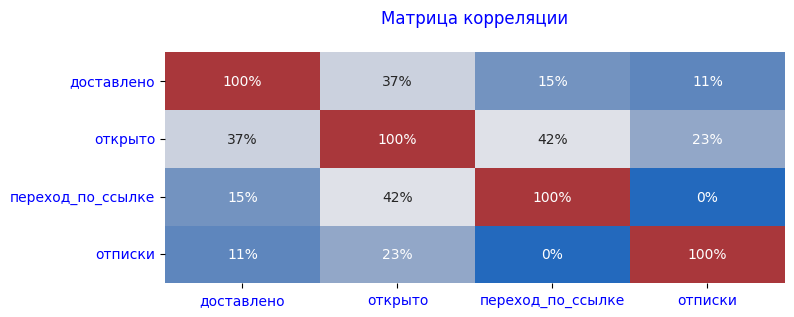


****************************************************************************************************
Шаблон 'Б'



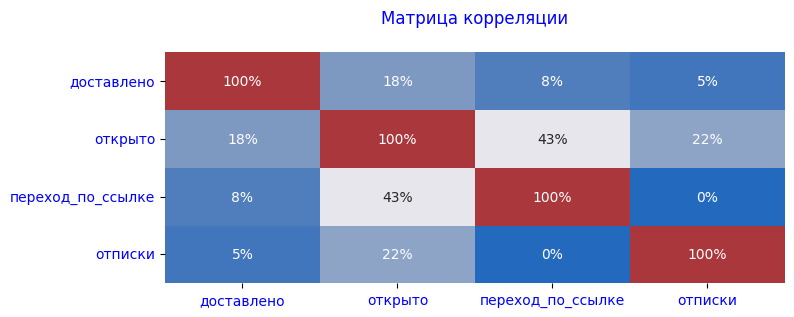

In [ ]:
# Посмотрим связь между числом клиентов на этапах
# Для параметрического ряда рассчиаем ранговую корреляцию Пирсона
for i in ['А', 'Б']:
  print()
  print('\033[33m\033[1m*'* 100)
  print(f"\033[33m\033[1mШаблон '{i}'")
  print()
  coef_corr(df.query('макет == @i')[['доставлено', 'открыто', 'переход_по_ссылке', 'отписки']])

Опираясь на шкалу Чеддока отметим:

|События|Шаблон А|Шаблон Б|Вывод|
|:---|:---|:---|:---|
доставлено - открыто|слабоя|очень слабая|Шаблон А лучше открывается
доставлено - переход_по_ссылке|очень слабая|очень слабая|Отличие отсутствует
доставлено - отписки|очень слабая|очень слабая|Отличие отсутствует
открыто - переход_по_ссылке|слабая|слабая|Отличие отсутствует
открыто - отписки|очень слабая|очень слабая|Отличие отсутствует



### Проведем статистический тест

Проверим, находят ли статистические критерии разницу между выборками - группами  А и Б. Будем проверять гипотезу о равенстве долей и применим z- тест.

В общем случае нулевая гипотеза будет формулироваться так: между клиентами групп А и Б отсутствует статистически значимая разница долей (конверсии) клиентов, совершивших переход на следующую ступень воронки и клиентов на екущей ступени воронки.
Сформулируем в общем случае альтернативную гипотезу: между клиентами групп А и Б существует статистически значимая разница долей (конверсии) клиентов, совершивших переход на следующую ступень воронки и клиентов на екущей ступени воронки.

Нам предстоит просести несколько сравнений, проводимых на одних и тех же данных — это множественный тест. Его важная особенность в том, что с каждой новой проверкой гипотезы растёт вероятность ошибки первого рода. Чтобы снизить вероятность ложнопозитивного результата при множественном тестировании гипотез, применяют разные методы корректировки уровня статистической значимости. Наиболее распостраненным, но при этом и наиболее грубым является Метод Бонферрони (поправка Бонферрони).




Какой тест нам следует выбрать? Результатам какого теста следует отдать приоритет при отличающихся результатах?

[Для Z-теста требуется большой размер выборки (n ≥ 30) и известная дисперсия генеральной совокупности (или отклонение). Если дисперсия генеральной совокупности неизвестна, используйте t-тест, который использует выборочное стандартное отклонение (s).](https://www.reneshbedre.com/blog/z-test-in-python.html)  

[Большие выборки (n>= 30), взятые из совокупности (N), демонстрируют приблизительное нормальное распределение средних значений выборки в соответствии с Центральной предельной теоремой (CLT). Для больших выборок может использоваться тестовая статистика z (z-score), соответствующая стандартному нормальному распределению (z distribution). Для данных меньшего размера выборки можно использовать тестовую статистику t (t-критерий Стьюдента)](https://www.reneshbedre.com/blog/hypothesis-testing)  

Мы применим оба рассмотренных теста, но при возникновении различий будеи отдавать предпочтение параметрическому z-тесту.

При этом при проведении Z-теста теория призывает нас проверить: известна ли нам дисперсия генеральной совокупности.   
В нашем исследовании мы ограничены выборками из генеральной совокупности. Прверить можем только дисперию предоставленных нам данных, которая по сути является выборкой.  
И тем не менее - проверим - можем ли мы вычислить дисперсию для выборок.


In [ ]:
# Формруем список столбцов для проверки дисперсии
count_dispertion = df.columns.to_list()[5:]
# Рассчитываем дисперсию
for i in count_dispertion:
    print('Столбец', i, '- дисперсия = ', round(variance(df[i]), 4))

Столбец отправлено - дисперсия =  0
Столбец доставлено - дисперсия =  0.2479
Столбец открыто - дисперсия =  0.0848
Столбец переход_по_ссылке - дисперсия =  0.018
Столбец отписки - дисперсия =  0.0084


Таким образом, нам известна дисперсия для каждой из ступеней воронки и мы можем провести Z-тест

### Актуальность контактов

Проверим, находят ли статистические критерии разницу между выборками групп А и Б для последовательности событий "отправлено" - "доставлено". Проверим гипотезу о равенстве долей.

Сформулируем нулевую гипотезу: между клиентами групп А и Б отсутствует статистически значимая разница доли (конверсии) клиентов, кому было отправлено сообщение и клиентов, кому было доставлено сообщение.  

Сформулируем альтернативную гипотезу: между клиентами групп А и Б существует статистически значимая разница доли (конверсии) клиентов, кому было отправлено сообщение и клиентов, кому было доставлено сообщение.  

In [ ]:
# Создадим датасеты (выборки) с клиетами группы А и группы Б
df_A = df[df['макет'] == "А"]
df_B = df[df['макет'] == "Б"]

In [ ]:
# Посмотрим соотношение между количеством  отправленных и доставленных сообщений внутри каждой группы.
sent_A = df_A['отправлено'].sum()
delivered_A = df_A['доставлено'].sum()
sent_B = df_B['отправлено'].sum()
delivered_B = df_B['доставлено'].sum()

Посмотрим долю доставленных к отправленным для группы А

In [ ]:
sent_deliv('A', sent_A, delivered_A, 'отправлено', 'доставлено')

Группа A
    отправлено - 25807
    доставлено - 10023
    конверсия 38.84%


In [ ]:
sent_deliv('Б', sent_B, delivered_B, 'отправлено', 'доставлено')

Группа Б
    отправлено - 16317
    доставлено - 12984
    конверсия 79.57%


Мы вновь видим, что доля доставки для группы Б значительно выше.

Посчитаем статистику.

In [ ]:
# критический уровень статистической значимости
alpha = .05
# поправка Бонферрони
bonferroni = 1

delivered = np.array([delivered_A, delivered_B])
sent = np.array([sent_A, sent_B])


In [ ]:
# проведем z - тест
z_test(delivered, sent, alpha)


          пропорция успехов в первой группе p1 =  0.3883829968613167 
          пропорция успехов во второй группе p2 = 0.7957345100202243
          пропорция успехов в комбинированном датасете p_combined = 0.5461732029246985
          разница пропорций в датасетах difference =  -0.4073515131589076
          z_value -81.80562881762842
z-test:
p-значение:  0.0
Отвергаем нулевую гипотезу: между долями есть значимая разница


Проверим t-test

In [ ]:
t_test(df_A, df_B, 'доставлено')

p-значение:  0.0
Нулевая гипотеза отвергнута. Принимаем альтернативную гипотезу


**Вывод:**  
Таким образом, между клиентами групп А и Б существует статистически значимая разница доли (конверсии) клиентов, кому было отправлено сообщение и клиентов, кому было доставлено сообщение.

Проведенный тест подтверждает наблюдение, сделанное ранее, на этапе построения воронки событий.

### Заинтересованность в предложении

Нам предстоит провести несколько сравнений, проводимых на одних и тех же данных — это множественный тест. Его важная особенность в том, что с каждой новой проверкой гипотезы растёт вероятность ошибки первого рода. Чтобы снизить вероятность ложнопозитивного результата при множественном тестировании гипотез, применяют разные методы корректировки уровня статистической значимости. Наиболее распостраненным, но при этом и наиболее грубым является Метод Бонферрони (поправка Бонферрони).

Далее мы проверим три гипотезы о равенстве долей для последовательности событий:
- 'доставлено' - 'открыто'
- 'открыто' - 'переход_по_ссылке'
- 'открыто' - 'отписки'

Учитывая сказанное примем размер поправки Бонферонни равным 3.



Проверим, находят ли статистические критерии разницу между выборками групп А и Б для последовательности событий 'доставлено' - 'открыто'. Проверим гипотезу о равенстве долей.

Сформулируем нулевую гипотезу: между клиентами групп А и Б отсутствует статистически значимая разница доли (конверсии) клиентов, кому было доставлено сообщение и клиентов, которы его открыли.  

Сформулируем альтернативную гипотезу: между клиентами групп А и Б существует статистически значимая разница доли (конверсии) клиентов, кому было доставлено сообщение и клиентов, которы его открыли.

Для удобства дальнейших расчетов код для расчета z- и t- критериев интегрирован в одну функцию: `prepear_test`   
Применим функцию `prepear_test` и **повторим расчет с погибшими**

In [ ]:
# df_A, df_B - созданные ранее выборки клиентов в зависимости от вида макета
# 'доставлено', 'открыто' - тестируемая последовательность событий
# alpha - установленный выше уровень статистической значимости (равен 0.05)
# 3 - значение поправки Бонферрони для этого теста
prepear_test(df_A, df_B, 'доставлено', 'открыто', alpha, 3)

Группа A
    доставлено - 10023
    открыто - 2065
    конверсия 20.60%
Группа Б
    доставлено - 12984
    открыто - 1875
    конверсия 14.44%
--------------------
Посчитаем статистику, проведем z-test

          пропорция успехов в первой группе p1 =  0.20602613987827995 
          пропорция успехов во второй группе p2 = 0.14440850277264325
          пропорция успехов в комбинированном датасете p_combined = 0.17125222758290956
          разница пропорций в датасетах difference =  0.0616176371056367
          z_value 12.301239121312625
z-test:
p-значение:  0.0
Отвергаем нулевую гипотезу: между долями есть значимая разница

t-test:
p-значение:  6.3258667783841e-31
Нулевая гипотеза отвергнута. Принимаем альтернативную гипотезу


**Вывод:**  
Таким образом, между клиентами групп А и Б существует статистически значимая разница доли (конверсии) клиентов, кому было доставлено сообщение и клиентов, которые его открыли.

Сообщения, высланные по шаблону А открываются чаще.  
Интерпретируем вывод и попробуем понять, чем обусловлено различие - выборкой клиентов или содержанием сообщения.  
С одной стороны, когда клиент получил соообщение и еще не принял решение - открыть его или нет - в этот момент клиен еще не знает содержания сообщения. Это говорит за объяснение различия за счет выборки клиентов.  
С другой стороны, сообщения содержат тему, которую видит клиент до открытия сообщения и которая дает ему общее представление о содержании сообщения. Кроме того, современные гаджеты в ряде случаев в режиме ожидания выводят на экран часть содержимого сообщения еще до открытия письма. Это говорит за объяснение различия за счет содержания сообщения.      
**Сказанное позволяет нам сделать вывод о том, что различие обусловлено содержанием сообщения.**


Проверим, находят ли статистические критерии разницу между выборками групп А и Б для последовательности событий 'открыто' - 'переход_по_ссылке'. Проверим гипотезу о равенстве долей.

Сформулируем нулевую гипотезу: между клиентами групп А и Б отсутствует статистически значимая разница доли (конверсии) клиентов, которые открыли сообщение и клиентов, которые перешли по ссылке.  

Сформулируем альтернативную гипотезу: между клиентами групп А и Б существует статистически значимая разница доли (конверсии) клиентов, которые открыли сообщение и клиентов, которые перешли по ссылке.

In [ ]:
 prepear_test(df_A, df_B, 'открыто', 'переход_по_ссылке', alpha, 3)

Группа A
    открыто - 2065
    переход_по_ссылке - 382
    конверсия 18.50%
Группа Б
    открыто - 1875
    переход_по_ссылке - 390
    конверсия 20.80%
--------------------
Посчитаем статистику, проведем z-test

          пропорция успехов в первой группе p1 =  0.18498789346246974 
          пропорция успехов во второй группе p2 = 0.208
          пропорция успехов в комбинированном датасете p_combined = 0.19593908629441625
          разница пропорций в датасетах difference =  -0.023012106537530247
          z_value -1.8174560366606916
z-test:
p-значение:  0.06914731411180086
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

t-test:
p-значение:  1.195951479866452e-10
Нулевая гипотеза отвергнута. Принимаем альтернативную гипотезу


**Вывод:**  
Таким образом, между клиентами групп А и Б отсутствует статистически значимая разница доли (конверсии) клиентов, которые открыли сообщение и клиентов, которые перешли по ссылке.  
Обратим внимание, что z- и t - тесты дают разные результаты. В соответствии со сделанным ранее заключением отдаем предпочтение z-тесту.




### Лояльность клиентов

Проверим, находят ли статистические критерии разницу между выборками групп А и Б для последовательности событий 'открыто' - 'отписки'. Проверим гипотезу о равенстве долей.

Сформулируем нулевую гипотезу: между клиентами групп А и Б отсутствует статистически значимая разница доли (конверсии) клиентов, которые открыли сообщение и клиентов, которые отписались от рассылки.  

Сформулируем альтернативную гипотезу: между клиентами групп А и Б существует статистически значимая разница доли (конверсии) клиентов, которые открыли сообщение и клиентов, которые отписались от рассылки.  

In [ ]:
 prepear_test(df_A, df_B, 'открыто', 'отписки', alpha, 3)

Группа A
    открыто - 2065
    отписки - 191
    конверсия 9.25%
Группа Б
    открыто - 1875
    отписки - 167
    конверсия 8.91%
--------------------
Посчитаем статистику, проведем z-test

          пропорция успехов в первой группе p1 =  0.09249394673123487 
          пропорция успехов во второй группе p2 = 0.08906666666666667
          пропорция успехов в комбинированном датасете p_combined = 0.09086294416243655
          разница пропорций в датасетах difference =  0.0034272800645682028
          z_value 0.373812711667315
z-test:
p-значение:  0.7085436614750829
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

t-test:
p-значение:  0.0029058506949159995
Нулевая гипотеза отвергнута. Принимаем альтернативную гипотезу


**Вывод:**  
Таким образом, между клиентами групп А и Б отсутствует статистически значимая разница доли (конверсии) клиентов, которые открыли сообщение и клиентов, которые отписались от рассылки.  
Обратим внимание, что z- и t - тесты дают разные результаты. В соответствии со сделанным ранее заключением отдаем предпочтение z-тесту.




### Сравним распределение клиентов между группами по возрасту

Чтобы провергнуть различия в распределении клиентов по возрасту -  сравним выборочные средние для выборок (для групп А и Б) и проведем двухсторонний t - тест.

In [ ]:
t_test(df_A, df_B, 'возраст')

p-значение:  0.905
Не удалось отвергнуть нулевую гипотезу. Принимаем нулевую гипотезу


**Вывод:** Клиенты по возрасту распределены равномерно между группами А и Б

### Сравним распределение клиентов между группами по гендеру

Чтобы провергнуть различия в распределении клиентов по гендеру - проверим гипотезу о равенстве долей (для групп А и Б) и проведем двухсторонний z - тест.

In [ ]:
# Посмотрим соотношение между общим количеством клиентов и клиентов - мужчин внутри каждой группы.
total_A = df_A['пол'].count()
men_A = df_A.query('пол == "М"')['пол'].count()
total_B = df_B['пол'].count()
men_B = df_B.query('пол == "М"')['пол'].count()

In [ ]:
# сформируем массивы
men = np.array([men_A, men_B])
total = np.array([total_A, total_B])

In [ ]:
# проведем тест
z_test(men, total, alpha)


          пропорция успехов в первой группе p1 =  0.4016352152516759 
          пропорция успехов во второй группе p2 = 0.4024024024024024
          пропорция успехов в комбинированном датасете p_combined = 0.4019323900864116
          разница пропорций в датасетах difference =  -0.0007671871507264894
          z_value -0.15644936038599153
z-test:
p-значение:  0.8756788321851485
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными


**Вывод:** Клиенты по гендеру распределены равномерно между группами А и Б

### **Вывод по результатам проведенных тестов:**  
1. Между клиентами групп А и Б отсутствует статистически значимая разница распределения клиентов по возрасту.

2. Между клиентами групп А и Б отсутствует статистически значимая разница доли клиентов - мужчик (и доли клиентов - женщин).

3. Между клиентами групп А и Б существует статистически значимая разница доли (конверсии) клиентов, кому было отправлено сообщение и клиентов, кому было доставлено сообщение. Эта разница не обусловлена различиями шаблона в сообщении

4. Мы проверили три гипотезы о равенстве долей для последовательности событий и получили результаты:
- 'доставлено' - 'открыто': гипотеза не подтверждена
- 'открыто' - 'переход_по_ссылке': гипотеза подтверждена
- 'открыто' - 'отписки': гипотеза подтверждена


5. Выводы, который мы должны сделать:
- между клиентами групп А и Б существует статистически значимая разница.
- сообщения, высланные по шаблону А, открываются чаще.
- сообщения, высланные по шаблону Б, доставляются вдвое чаще, что может говорить о более качественной и актуальной контактной информации для этой группы.




# 5.3 Различия в сегментах.


Для более качественной оценки проведенного теста разобьем клиентов на сегменты:
- по возрасту на диапазоны (для удобства обработки и восприятия обозначим диапазоны цифрами):
 - до 27 лет - 20
 - от 28 лет включительно до 40 лет - 30
 - от 40 лет включительно - 40
- по гендеру (полу).


- Оценим, как сегменты отреагировали на рассылку в рамках каждого макета
- Выясним, какой из шаблонов в перспективных рассылках лучше всего отправлять клиентам


Повторим проведенное выше исследование:
- постоим воронку событий
- сформулируем гипотезы и проведем статистический тест


Последовательность событий "отправлено" - "доставлено" оценена  нами ранее для всей представленной выборки, рекомендации по ней не зависят от сегментов по этой причине эту последовательность мы исключим из рассмотрения в настоящем пункте исследования.


Далее мы проведем исследования для последовательности событий:
- 'доставлено' - 'открыто'
- 'открыто' - 'переход_по_ссылке' - заинтересованность в предложении
- 'открыто' - 'отписки'- лояльность клиентов


Мы будем исследовать поведение клиентов по шести сегментам. Но каждый сегмент будет представлять собой отдельное исследование. По этой причине мы оставим значение поправки Бонферрони равным 3 и не будем умножать его на 6 (на 6 исследований).


### Заинтересованность в предложении



#### Воронка событий
Построим воронку для последовательности событий 'доставлено' - 'открыто' - 'переход_по_ссылке' для каждого из макетов

In [ ]:
# Осуществим перебор комбинаций сегментов:
# Для уникальных значений столбца "возраст_сегм"
for i in sorted(df['возраст_сегм'].unique()):
  # Для уникальных значений столбца "пол"
  for j in sorted(df['пол'].unique()):
    # Переберем комбинации
    print(f"\033[33m\033[1mДиапазон возраста '{i}', гендер '{j}'")
    print()
    # Построим воронку событий
    grouping_events(df.loc[(df['возраст_сегм'] == i) & (df['пол'] == j)]\
            .groupby('макет').agg({'доставлено':'sum','открыто':'sum', 'переход_по_ссылке':'sum'})\
            .T.reset_index())
    print()
    print('\033[33m\033[1m*' * 100)
    print()


Диапазон возраста '20', гендер 'Ж'

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,630,-,100.0%,865,-,100.0%
1,открыто,87,13.8%,13.8%,63,7.3%,7.3%
2,переход_по_ссылке,11,12.6%,1.7%,12,19.0%,1.4%



Визуализируем воронку событий для обоих шаблонов




****************************************************************************************************

Диапазон возраста '20', гендер 'М'

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,229,-,100.0%,313,-,100.0%
1,открыто,32,14.0%,14.0%,23,7.3%,7.3%
2,переход_по_ссылке,4,12.5%,1.7%,4,17.4%,1.3%


...


Визуализируем воронку событий для обоих шаблонов




****************************************************************************************************

Диапазон возраста '40', гендер 'М'

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,1105,-,100.0%,1453,-,100.0%
1,открыто,314,28.4%,28.4%,318,21.9%,21.9%
2,переход_по_ссылке,59,18.8%,5.3%,65,20.4%,4.5%



Визуализируем воронку событий для обоих шаблонов




****************************************************************************************************



Во всех шести сегментах подтверждается выявленная ранее тенденция:
- чаще открывается сообщение с шаблоном А
- но переход по ссылке чаще совершают по письмам с шаблоном Б
- конечная конверсия перехода по ссылке к доставленным сообщениям больше у шаблона А

**Вывод:**  
Очевидно, что содержание письма с шаблоном Б больше мотивирует клиентов перейти по ссылке.  
Нужно выяснить, что мотивирует клиентов с шаблоном А открывать письмо чаще. Можно предположить, что это тема письма и первые его строчки.  
В таком случае необходимо доработать эти параметры, чтобы соединить преимущества каждого из шаблонов.

Но не доверимся вигуализации и проведем статистический тест

#### Статистический тест

Поскольку на данном этапе мы выясняем наличие или отсутствие статистически значимой разницы для последовательности событий 'доставлено', 'открыто', 'переход по ссылке' и не включаем в последовательность событие 'отписки', то мы можем утверждать, что проверяем две гипотезы и принимаем попраку Бонферрони равной 2.

In [ ]:
# Осуществим перебор комбинаций сегментов
# Применим функцию и проведем тест
# Сравниваем события 'доставлено', 'открыто',
# уровень alpha по умолчанию равен 0.05, поправка Бонферрони равна 2
iterate_over_segments(df, 'доставлено', 'открыто', 2)

Диапазон возраста '20', гендер 'Ж'

Группа A
    доставлено - 630
    открыто - 87
    конверсия 13.81%
Группа Б
    доставлено - 865
    открыто - 63
    конверсия 7.28%
--------------------
Посчитаем статистику, проведем z-test

          пропорция успехов в первой группе p1 =  0.1380952380952381 
          пропорция успехов во второй группе p2 = 0.07283236994219654
          пропорция успехов в комбинированном датасете p_combined = 0.10033444816053512
          разница пропорций в датасетах difference =  0.06526286815304157
          z_value 4.147231793052319
z-test:
p-значение:  3.365193262161448e-05
Отвергаем нулевую гипотезу: между долями есть значимая разница

t-test:
p-значение:  0.5298842067601957
Не удалось отвергнуть нулевую гипотезу. Принимаем нулевую гипотезу

****************************************************************************************************

Диапазон возраста '20', гендер 'М'

Группа A
    доставлено - 229
    открыто - 32
    конверсия 13.97%
Группа Б
 

In [ ]:
# Осуществим перебор комбинаций сегментов
# Применим функцию и проведем тест
# Сравниваем события 'открыто', 'переход_по_ссылке',
# уровень alpha по умолчанию равен 0.05, поправка Бонферрони равна 2
iterate_over_segments(df, 'открыто', 'переход_по_ссылке', 2)

Диапазон возраста '20', гендер 'Ж'

Группа A
    открыто - 87
    переход_по_ссылке - 11
    конверсия 12.64%
Группа Б
    открыто - 63
    переход_по_ссылке - 12
    конверсия 19.05%
--------------------
Посчитаем статистику, проведем z-test

          пропорция успехов в первой группе p1 =  0.12643678160919541 
          пропорция успехов во второй группе p2 = 0.19047619047619047
          пропорция успехов в комбинированном датасете p_combined = 0.15333333333333332
          разница пропорций в датасетах difference =  -0.06403940886699505
          z_value -1.0743779004318834
z-test:
p-значение:  0.2826533432569134
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

t-test:
p-значение:  0.23751601298757127
Не удалось отвергнуть нулевую гипотезу. Принимаем нулевую гипотезу

****************************************************************************************************

Диапазон возраста '20', гендер 'М'

Группа A
    открыто - 32
    переход_по_ссылке 

Две проведенные серии тестов показывают:
- последовательность событий "доставлено" - "открыто" имеет статистически значимую разницу для каждого из рассмотренных сегментов
- по результатам z-теста последовательность событий "открыто" - "переход по ссылке" не имеет статистически значимой разницы для каждого из рассмотренных сегментов
 - вместе с тем t-тест для последовательности событий "открыто" - "переход по ссылке" показывает наличие статистически значимой разницы для сегментов возрастных групп старше 29 лет для обоих генднров. В совокупности с наблюдением по результатам построения воронки можно предположить возможность выяснить, что мотивирует клиентов с шаблоном А открывать письмо чаще. Можно предположить, что это тема письма и первые его строчки. В таком случае необходимо доработать эти параметры, чтобы соединить преимущества каждого из шаблонов.


**Вывод:**  
- Сообщения по шаблону А приводят к лучшей конверсии из доставленных в переход по ссылке для каждого из сегментов.
- Можно рекомендовать доработать шаблон А с учетом преимуществ шаблона Б, чтобы повысить конверсию перехода из события "открыто" в событие "переход по ссылке" для шаблона А

### Лояльность клиентов


#### Воронка событий
Построим воронку для последовательности событий 'доставлено' - 'открыто' - 'отписки' для каждого из макетов

In [ ]:
# Осуществим перебор комбинаций сегментов:
# Для уникальных значений столбца "возраст_сегм"
for i in sorted(df['возраст_сегм'].unique()):
  # Для уникальных значений столбца "пол"
  for j in sorted(df['пол'].unique()):
    # Переберем комбинации
    print(f"\033[33m\033[1mДиапазон возраста '{i}', гендер '{j}'")
    print()
    # Построим воронку событий
    grouping_events(df.loc[(df['возраст_сегм'] == i) & (df['пол'] == j)]\
            .groupby('макет').agg({'доставлено':'sum','открыто':'sum', 'отписки':'sum'})\
            .T.reset_index())
    print()
    print('\033[33m\033[1m*' * 100)
    print()


Диапазон возраста '20', гендер 'Ж'

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,630,-,100.0%,865,-,100.0%
1,открыто,87,13.8%,13.8%,63,7.3%,7.3%
2,отписки,5,5.7%,0.8%,8,12.7%,0.9%



Визуализируем воронку событий для обоих шаблонов




****************************************************************************************************

Диапазон возраста '20', гендер 'М'

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,229,-,100.0%,313,-,100.0%
1,открыто,32,14.0%,14.0%,23,7.3%,7.3%
2,отписки,2,6.2%,0.9%,5,21.7%,1.6%


...


Визуализируем воронку событий для обоих шаблонов




****************************************************************************************************

Диапазон возраста '40', гендер 'М'

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,1105,-,100.0%,1453,-,100.0%
1,открыто,314,28.4%,28.4%,318,21.9%,21.9%
2,отписки,31,9.9%,2.8%,19,6.0%,1.3%



Визуализируем воронку событий для обоих шаблонов




****************************************************************************************************



Мы видим, что в сегменте возраста до 28 лет и женщины и мужчины отписываются от рассылок значительно чаще при шаблоне Б.   
В двух других возрастных сегментах и женщины и мужчины отписываются от рассылок значительно чаще наоборот - при шаблоне А, что укладывается в нблюдение в целом по всей предоставленной выборке.  

Однако не будем спешить с выводом о том, что клиентав в возрасте до 28 лет предпочтительнее высылать шаблон А. Посмотрим на количество клиентов в выборках и увидим, что для этого сегмента количество клиентов на этапе "отписки" находится в диапазоне от 2 до 8 человек, что позволяет усомниться в достаточности данных для интерпретации наблюдения.  
Отложим выводы и проведем статистический тест.

#### Статистический тест

Поскольку на данном этапе мы выясняем наличие или отсутствие статистически значимой разницы для последовательности событий 'доставлено', 'открыто', 'отписки' и не включаем в последовательность событие 'переход по ссылке', то мы можем утверждать, что проверяем две гипотезы и принимаем поправку Бонферрони равной 2.

In [ ]:
# Осуществим перебор комбинаций сегментов
# Применим функцию и проведем тест
# Сравниваем события 'открыто', 'отписки',
# уровень alpha по умолчанию равен 0.05, поправка Бонферрони равна 2
iterate_over_segments(df, 'открыто', 'отписки', 2)

Диапазон возраста '20', гендер 'Ж'

Группа A
    открыто - 87
    отписки - 5
    конверсия 5.75%
Группа Б
    открыто - 63
    отписки - 8
    конверсия 12.70%
--------------------
Посчитаем статистику, проведем z-test

          пропорция успехов в первой группе p1 =  0.05747126436781609 
          пропорция успехов во второй группе p2 = 0.12698412698412698
          пропорция успехов в комбинированном датасете p_combined = 0.08666666666666667
          разница пропорций в датасетах difference =  -0.06951286261631089
          z_value -1.493512096402691
z-test:
p-значение:  0.135303190258933
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

t-test:
p-значение:  0.1364313565489519
Не удалось отвергнуть нулевую гипотезу. Принимаем нулевую гипотезу

****************************************************************************************************

Диапазон возраста '20', гендер 'М'

Группа A
    открыто - 32
    отписки - 2
    конверсия 6.25%
Группа Б
   

Параметрический Z - тест отвергает нулевую гипотезу для каждого из шести сегментов и не находит статистически значимой разницы между долями.  
Самое время вспомнить, что мы работаем на этом этапе с маленькими выборками, менее 30 элементов и можем довериться t-критерию Стьюдента. Последний отвергает нулевую гипотезу в сегменте Диапазон возраста от 28 до 40 лет для мужчин. В остальных случаях критерий не находит значимой разницы. Но и в этом случае выборка этапа "отписки" составляет по 62 человека в каждой группе, что заставляет нас отдать приоритет Z-тесту.

**Вывод:**   
Отсутствует статистически значимая разница количества отписок относительно открытых сообщений между шаблонами сообщений.

## 5.4 Дополнительная сегментация по возрасту
Ранее мы обратили внимание, что возрастной сегмент "30" - от 28 до 40 лет - занимает 64% от всех клиентов. Это не позволяет говорить о равномерной сегментации и дает возможность разбить этот сегмент на части.  
Учитывая, что медиана и среднее для возраста клиентов составляет 35 лет, разобьем сегмент "30" на части:
- от 28 до 35 лет - обозначим как сегмент "33"
- от 35 до 40 лет - обозначим как сегмент "37"

Для упрощения сформируем новый датафрейм, в котором оставим только клиентов в возрасте от (включительно) 28 до (не включая) 40 лет

In [ ]:
df_35 = df.query('возраст_сегм == 30')

In [ ]:
# Добавим сегментацию по возрасту
# Добавим новый столбец
#df_35.insert (loc= 4 , column='возраст_сегм_', value=20)
# Произведем сегментацию
df_35.loc[df_35['возраст'] >= 28, 'возраст_сегм'] = 33
df_35.loc[df_35['возраст'] >= 35, 'возраст_сегм'] = 37

In [ ]:
# Посмотрим, как распределились клиенты
df_35.groupby('возраст_сегм').agg({'номер_клиента':'count'})

,номер_клиента
возраст_сегм,
33,14781
37,13224


Повторим расчеты, построение воронки и статистические тесты для новых сегментов

### Заинтересованность в предложении



#### Воронка событий
Построим воронку для последовательности событий 'доставлено' - 'открыто' - 'переход_по_ссылке' для каждого из макетов

In [ ]:
# Осуществим перебор комбинаций сегментов:
# Для уникальных значений столбца "возраст_сегм"
for i in sorted(df_35['возраст_сегм'].unique()):
  # Для уникальных значений столбца "пол"
  for j in sorted(df_35['пол'].unique()):
    # Переберем комбинации
    print(f"\033[33m\033[1mДиапазон возраста '{i}', гендер '{j}'")
    print()
    # Построим воронку событий
    grouping_events(df_35.loc[(df_35['возраст_сегм'] == i) & (df_35['пол'] == j)]\
            .groupby('макет').agg({'доставлено':'sum','открыто':'sum', 'переход_по_ссылке':'sum'})\
            .T.reset_index())
    print()
    print('\033[33m\033[1m*' * 100)
    print()


Диапазон возраста '33', гендер 'Ж'

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,2161,-,100.0%,2866,-,100.0%
1,открыто,357,16.5%,16.5%,337,11.8%,11.8%
2,переход_по_ссылке,61,17.1%,2.8%,83,24.6%,2.9%



Визуализируем воронку событий для обоих шаблонов




****************************************************************************************************

Диапазон возраста '33', гендер 'М'

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,1360,-,100.0%,1705,-,100.0%
1,открыто,276,20.3%,20.3%,254,14.9%,14.9%
2,переход_по_ссылке,47,17.0%,3.5%,44,17.3%,2.6%


...


Визуализируем воронку событий для обоих шаблонов




****************************************************************************************************

Диапазон возраста '37', гендер 'М'

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,1369,-,100.0%,1721,-,100.0%
1,открыто,378,27.6%,27.6%,321,18.7%,18.7%
2,переход_по_ссылке,67,17.7%,4.9%,66,20.6%,3.8%



Визуализируем воронку событий для обоих шаблонов




****************************************************************************************************



Во всех четырех сегментах подтверждается выявленная ранее тенденция:
- чаще открывается сообщение с шаблоном А
- но переход по ссылке чаще совершают по письмам с шаблоном Б - кроме сегмента Диапазон возраста '37', гендер 'Ж'
- конечная конверсия перехода по ссылке к доставленным сообщениям больше у шаблона А - кроме сегмента Диапазон возраста '33', гендер 'Ж', где конверсия одинаковая

**Вывод:**  
Очевидно, что содержание письма с шаблоном Б больше мотивирует клиентов перейти по ссылке.  


Но не доверимся вигуализации и проведем статистический тест

#### Статистический тест

Поскольку на данном этапе мы выясняем наличие или отсутствие статистически значимой разницы для последовательности событий 'доставлено', 'открыто', 'переход по ссылке' и не включаем в последовательность событие 'отписки', то мы можем утверждать, что проверяем две гипотезы и принимаем попраку Бонферрони равной 2.

In [ ]:
# Осуществим перебор комбинаций сегментов
# Применим функцию и проведем тест
# Сравниваем события 'доставлено', 'открыто',
# уровень alpha по умолчанию равен 0.05, поправка Бонферрони равна 2
iterate_over_segments(df_35, 'доставлено', 'открыто', 2)

Диапазон возраста '33', гендер 'Ж'

Группа A
    доставлено - 2161
    открыто - 357
    конверсия 16.52%
Группа Б
    доставлено - 2866
    открыто - 337
    конверсия 11.76%
--------------------
Посчитаем статистику, проведем z-test

          пропорция успехов в первой группе p1 =  0.16520129569643682 
          пропорция успехов во второй группе p2 = 0.11758548499651082
          пропорция успехов в комбинированном датасете p_combined = 0.13805450566938532
          разница пропорций в датасетах difference =  0.047615810699926
          z_value 4.845036155910101
z-test:
p-значение:  1.265886239831815e-06
Отвергаем нулевую гипотезу: между долями есть значимая разница

t-test:
p-значение:  6.225548092720684e-07
Нулевая гипотеза отвергнута. Принимаем альтернативную гипотезу

****************************************************************************************************

Диапазон возраста '33', гендер 'М'

Группа A
    доставлено - 1360
    открыто - 276
    конверсия 20.29%
Групп

In [ ]:
# Осуществим перебор комбинаций сегментов
# Применим функцию и проведем тест
# Сравниваем события 'открыто', 'переход_по_ссылке',
# уровень alpha по умолчанию равен 0.05, поправка Бонферрони равна 2
iterate_over_segments(df_35, 'открыто', 'переход_по_ссылке', 2)

Диапазон возраста '33', гендер 'Ж'

Группа A
    открыто - 357
    переход_по_ссылке - 61
    конверсия 17.09%
Группа Б
    открыто - 337
    переход_по_ссылке - 83
    конверсия 24.63%
--------------------
Посчитаем статистику, проведем z-test

          пропорция успехов в первой группе p1 =  0.17086834733893558 
          пропорция успехов во второй группе p2 = 0.24629080118694363
          пропорция успехов в комбинированном датасете p_combined = 0.207492795389049
          разница пропорций в датасетах difference =  -0.07542245384800805
          z_value -2.4488763715760733
z-test:
p-значение:  0.014330262509390401
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

t-test:
p-значение:  2.6206868253943643e-05
Нулевая гипотеза отвергнута. Принимаем альтернативную гипотезу

****************************************************************************************************

Диапазон возраста '33', гендер 'М'

Группа A
    открыто - 276
    переход_по_ссылк

Две проведенные серии тестов показывают:
- последовательность событий "доставлено" - "открыто" имеет статистически значимую разницу для каждого из рассмотренных сегментов
- по результатам z-теста последовательность событий "открыто" - "переход по ссылке" не имеет статистически значимой разницы для каждого из рассмотренных сегментов

**Вывод:**  
- Сообщения по шаблону А приводят к лучшей конверсии из доставленных в переход по ссылке для каждого из сегментов.


### Лояльность клиентов


#### Воронка событий
Построим воронку для последовательности событий 'доставлено' - 'открыто' - 'отписки' для каждого из макетов

In [ ]:
# Осуществим перебор комбинаций сегментов:
# Для уникальных значений столбца "возраст_сегм"
for i in sorted(df_35['возраст_сегм'].unique()):
  # Для уникальных значений столбца "пол"
  for j in sorted(df_35['пол'].unique()):
    # Переберем комбинации
    print(f"\033[33m\033[1mДиапазон возраста '{i}', гендер '{j}'")
    print()
    # Построим воронку событий
    grouping_events(df_35.loc[(df_35['возраст_сегм'] == i) & (df_35['пол'] == j)]\
            .groupby('макет').agg({'доставлено':'sum','открыто':'sum', 'отписки':'sum'})\
            .T.reset_index())
    print()
    print('\033[33m\033[1m*' * 100)
    print()


Диапазон возраста '33', гендер 'Ж'

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,2161,-,100.0%,2866,-,100.0%
1,открыто,357,16.5%,16.5%,337,11.8%,11.8%
2,отписки,36,10.1%,1.7%,26,7.7%,0.9%



Визуализируем воронку событий для обоих шаблонов




****************************************************************************************************

Диапазон возраста '33', гендер 'М'

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,1360,-,100.0%,1705,-,100.0%
1,открыто,276,20.3%,20.3%,254,14.9%,14.9%
2,отписки,25,9.1%,1.8%,40,15.7%,2.3%


...


Визуализируем воронку событий для обоих шаблонов




****************************************************************************************************

Диапазон возраста '37', гендер 'М'

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,1369,-,100.0%,1721,-,100.0%
1,открыто,378,27.6%,27.6%,321,18.7%,18.7%
2,отписки,37,9.8%,2.7%,22,6.9%,1.3%



Визуализируем воронку событий для обоих шаблонов




****************************************************************************************************



Мы видим, что в сегменте Диапазон возраста '33', гендер 'Ж' и Диапазон возраста '37', гендер 'М'
отписываются от рассылок значительно чаще при шаблоне А.   

Отложим выводы и проведем статистический тест.

#### Статистический тест

Поскольку на данном этапе мы выясняем наличие или отсутствие статистически значимой разницы для последовательности событий 'доставлено', 'открыто', 'отписки' и не включаем в последовательность событие 'переход по ссылке', то мы можем утверждать, что проверяем две гипотезы и принимаем поправку Бонферрони равной 2.

In [ ]:
# Осуществим перебор комбинаций сегментов
# Применим функцию и проведем тест
# Сравниваем события 'открыто', 'отписки',
# уровень alpha по умолчанию равен 0.05, поправка Бонферрони равна 2
iterate_over_segments(df_35, 'открыто', 'отписки', 2)

Диапазон возраста '33', гендер 'Ж'

Группа A
    открыто - 357
    отписки - 36
    конверсия 10.08%
Группа Б
    открыто - 337
    отписки - 26
    конверсия 7.72%
--------------------
Посчитаем статистику, проведем z-test

          пропорция успехов в первой группе p1 =  0.10084033613445378 
          пропорция успехов во второй группе p2 = 0.0771513353115727
          пропорция успехов в комбинированном датасете p_combined = 0.0893371757925072
          разница пропорций в датасетах difference =  0.023689000822881084
          z_value 1.093505956003926
z-test:
p-значение:  0.2741717153838592
Не получилось отвергнуть нулевую гипотезу, нет оснований считать доли разными

t-test:
p-значение:  0.6793541856932872
Не удалось отвергнуть нулевую гипотезу. Принимаем нулевую гипотезу

****************************************************************************************************

Диапазон возраста '33', гендер 'М'

Группа A
    открыто - 276
    отписки - 25
    конверсия 9.06%
Группа Б

Параметрический Z - тест отвергает нулевую гипотезу для каждого из шести сегментов и не находит статистически значимой разницы между долями.  
Вместе с тем t- критерий показывает наличие разницы в сегменте Диапазон возраста '33', гендер 'М' - в нем согласно данным построенной воронки по шаблону Б отписывается больше клиентов

**Вывод:**   
Отсутствует статистически значимая разница количества отписок относительно открытых сообщений между шаблонами сообщений - кроме Диапазон возраста '33', гендер 'М'

# Логарифмическая шкала.
Для лучшей читаемости воронки предпринята попытка применить логарифмическую шкалу.  
При этом искажается вычисление конверсии.  
Поэтому от использования логарифмической шкалы отказался.

In [ ]:
# Сгруппируем данные, сформируем датафрейм для построения воронки
clients_pie_log = df.groupby('макет').agg({'доставлено':'sum','открыто':'sum', 'переход_по_ссылке':'sum'})\
        .T.reset_index()
# Построим воронку
clients_pie_log

макет,index,А,Б
0,доставлено,10023,12984
1,открыто,2065,1875
2,переход_по_ссылке,382,390


In [ ]:
pd.options.display.float_format = '{:.3}'.format

In [ ]:
clients_pie_log['log_A'] = np.log10(clients_pie_log['А'])
clients_pie_log['log_B'] = np.log10(clients_pie_log['Б'])

In [ ]:
clients_pie_log

макет,index,А,Б,log_A,log_B
0,доставлено,10023,12984,4.0,4.11
1,открыто,2065,1875,3.31,3.27
2,переход_по_ссылке,382,390,2.58,2.59


In [ ]:
clients_pie_log = clients_pie_log[['index', 'log_A', 'log_B']]

In [ ]:
grouping_events(clients_pie_log)

Таблица конверсии


,event,clients_id_a,conv_a,conv_a_to_fst_step,clients_id_b,conv_b,conv_b_to_fst_step
0,доставлено,400.1%,-,100.0%,411.3%,-,100.0%
1,открыто,331.5%,82.9%,82.9%,327.3%,79.6%,79.6%
2,переход_по_ссылке,258.2%,77.9%,64.5%,259.1%,79.2%,63.0%



Визуализируем воронку событий для обоих шаблонов



In [ ]:
print(f'Длительность исполнения  {round(time.time() - start_time)} секунд')


Длительность исполнения  23 секунд


# 6 Выводы и рекомендации
## 6.1 Программные средства и алгоритм решения
Поставленная задача решена в тетрадке Python с использованием:
- библиотек pandas, numpy, scipy, math, statistics для анализа и стратистики,
- библиотек matplotlib, seaborn, plotly для визуализации,
- google.colab и os для управления расположением данных.  
Алгоритм исследования и общий его ход описаны во вступительной части.  

## 6.2 Выбор воронки событий и статистического теста  
**Выбор воронок событий.**  
Для анализа выбраны три воронки событий:
- последовательность событий 'отправлено' - 'доставлено' характеризует актуальность контактов.
- последовательность событий 'доставлено' - 'открыто' - 'переход_по_ссылке' характеризует заинтересованность клиента в предложении
- последовательность событий 'доставлено' - 'открыто' - отписки' характеризует лояльность клиента

**Выбор статистического теста.**  
Приоритет отдан z-тесту по причине того, что для него требуется большой размер выборки (n ≥ 30) и известная дисперсия генеральной совокупности (или выборки).  
Вместе с тем в анализе оставлена возможность применения t-критерия Стьюдента

## 6.3 Дополнительные действия
- Оценена актупльность контактов
- Сегмент клиентов от 28 до 40 лет занимает 64% от всех клиентов. Сегмент разбит на две части, по которым построена воронка и произведена гипотеза  

## 6.4 Выводы из исследования. Как сегменты отреагировали на рассылку в рамках каждого макета
- Заинтересованность в предложении. Сообщения по шаблону А приводят к лучшей конверсии из доставленных в переход по ссылке для каждого из сегментов.
- Лояльность. Отсутствует статистически значимая разница количества отписок относительно открытых сообщений между шаблонами сообщений - кроме Диапазон возраста 'от 28 до 35 лет', гендер 'Мужской'

## 6.5 Рекомендации.  
- Выяснить, что мотивирует клиентов с шаблоном А открывать письмо чаще. Можно предположить, что это тема письма и первые его строчки.
- Доработать шаблон А с учетом преимуществ шаблона Б, чтобы повысить конверсию перехода из события "открыто" в событие "переход по ссылке" для шаблона А (а по результатам теста этот переход лучше для шаблона Б).
- До доработки - отправлять сообщения по шаблону А для всех клиентов (для любого сегмента клиентов)
- Актуализировать контакты клиентов (на примере клиентов с шаблоном А - приводит к большей конечной конверсии переходов по ссылке по сравнению с клиентами с шаблоном Б).
 - Целесообразно обновлять данные клиентов на постоянной основе.
 - Целесообразно делать подобные рассылки чаще, чтобы заинтересовывать клиентов в продукте своего банка, не допускать их перетока к конкурентам








